In [3]:
import torch

print("CUDA Available:", torch.cuda.is_available())

print("GPU Name:", torch.cuda.get_device_name(0))

CUDA Available: False


AssertionError: Torch not compiled with CUDA enabled

TensorFlow Version: 2.21.0
Using CPU
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 25s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 4s 1us/step
Epoch 1/15


C:\Users\kumar\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7961 - loss: 0.5930 - val_accuracy: 0.8573 - val_loss: 0.4018
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8434 - loss: 0.4344 - val_accuracy: 0.8664 - val_loss: 0.3645
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8566 - loss: 0.3931 - val_accuracy: 0.8689 - val_loss: 0.3587
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8642 - loss: 0.3701 - val_accuracy: 0.8645 - val_loss: 0.3660
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8711 - loss: 0.3517 - val_accuracy: 0.8823 - val_loss: 0.3285
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8752 - loss: 0.3393 - val_accuracy: 0.8751 - val_loss: 0.3361
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8807 - loss: 0.3254 - val_accuracy: 0.8822 - val_loss: 0.3179
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8835 - loss: 0.3136 - val_accuracy: 0.8832 - val_

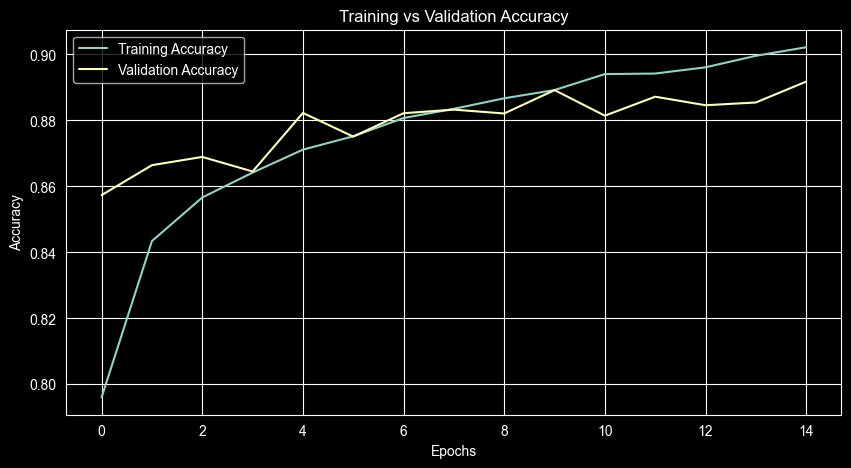

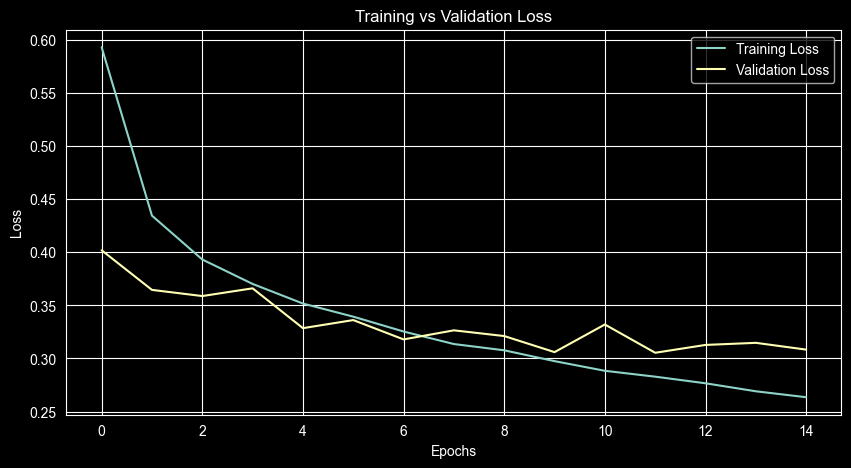

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


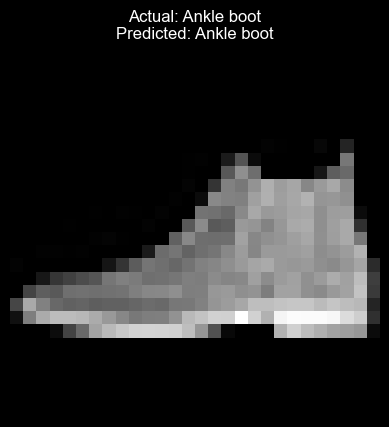


Prediction Probabilities:

[8.5135707e-07 2.4152905e-07 8.7769712e-07 5.1771048e-07 2.2719121e-06
 8.5767853e-04 1.7544244e-06 1.3748222e-03 2.9569978e-06 9.9775809e-01]


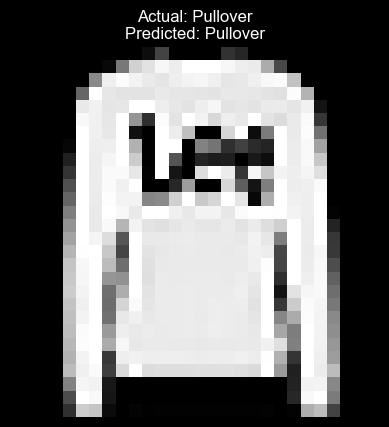


Prediction Probabilities:

[3.9385664e-06 1.9469493e-09 9.9468392e-01 1.6125153e-08 3.3168586e-03
 1.1009999e-08 1.9952385e-03 1.7272158e-09 1.0575832e-09 9.8398967e-10]


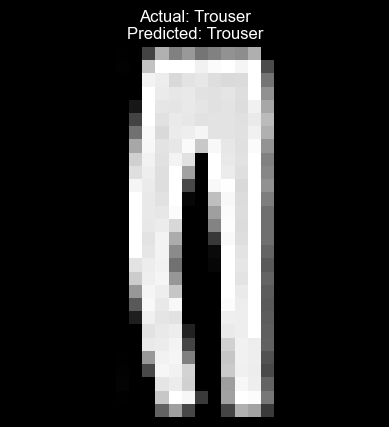


Prediction Probabilities:

[8.6493565e-06 9.9998486e-01 3.6186475e-06 3.7846917e-07 1.3764739e-07
 7.2828975e-08 2.1436811e-06 5.3892473e-09 7.3184170e-09 6.6716105e-08]


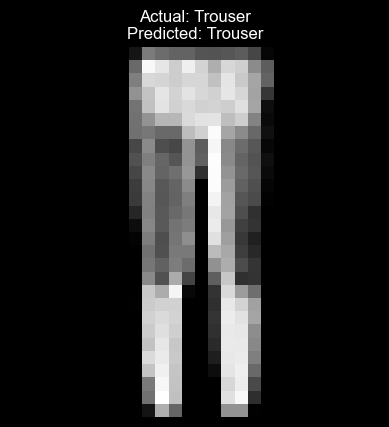


Prediction Probabilities:

[3.6196315e-07 9.9999392e-01 2.2978688e-06 2.2105606e-07 1.1243350e-06
 7.3229963e-08 1.9355957e-06 2.4306013e-09 8.8194907e-10 1.1781457e-08]


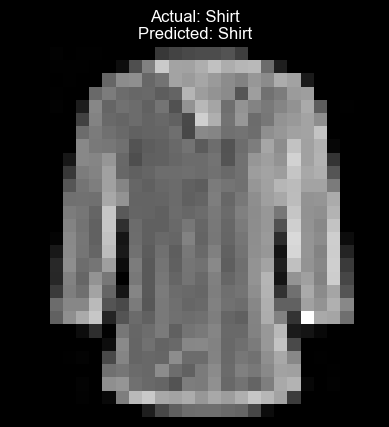


Prediction Probabilities:

[3.7573162e-02 4.1062312e-06 2.2583541e-02 1.7904119e-04 3.3234048e-03
 1.6890765e-06 9.3631905e-01 9.4607111e-07 1.2424603e-05 2.5901581e-06]


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.datasets import fashion_mnist

# =========================================
# CHECK GPU
# =========================================

print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU is ACTIVE")
else:
    print("Using CPU")

# =========================================
# LOAD DATASET
# =========================================

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

# =========================================
# CLASS NAMES
# =========================================

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# =========================================
# BUILD MODEL
# =========================================

model = Sequential([

    # Convert 28x28 → 784
    Flatten(input_shape=(28, 28)),

    # Hidden Layer 1
    Dense(256),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.3),

    # Hidden Layer 2
    Dense(128),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.3),

    # Hidden Layer 3
    Dense(64),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    # Output Layer
    Dense(10, activation='softmax')
])

# =========================================
# COMPILE MODEL
# =========================================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================
# TRAIN MODEL
# =========================================

history = model.fit(

    x_train,
    y_train,

    epochs=15,

    batch_size=64,

    validation_split=0.2
)

# =========================================
# EVALUATE MODEL
# =========================================

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("\nTest Accuracy:", test_accuracy)

# =========================================
# VISUALIZE ACCURACY
# =========================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

# =========================================
# VISUALIZE LOSS
# =========================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

# =========================================
# MAKE PREDICTIONS
# =========================================

predictions = model.predict(x_test)

# =========================================
# SHOW TEST IMAGES
# =========================================

for i in range(5):

    plt.imshow(x_test[i], cmap='gray')

    predicted_label = np.argmax(predictions[i])

    actual_name = class_names[y_test[i]]

    predicted_name = class_names[predicted_label]

    plt.title(
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}"
    )

    plt.axis('off')

    plt.show()

    print("\nPrediction Probabilities:\n")

    print(predictions[i])

    print("="*50)